<a href="https://colab.research.google.com/github/MuhammadAhmed196/flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/MuhammadAhmed196/flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

Research question:

Which content pages should be prioritized for human review for a possible refresh, using page-level search visibility and freshness signals that are available at the decision time?

Decision supported:

The output supports an editor or content team in deciding which pages to review first when refresh capacity is limited. The ranking is decision-support rather than an instruction to automatically change a page.

My provisional baseline prioritizes pages that are both stale and visible: pages with at least 180 days since the last update and at least 500 impressions in the last 90 days. The Week-4 baseline achieved Precision@50 of 0.620 on the evaluated test setup, while the Week-5 Random Forest achieved 0.560 on the same client-grouped holdout, so the baseline is retained as the current decision-support approach.

In [1]:
# ---------------------------------------------------------
# CAPSTONE QUESTION CHECK
# ---------------------------------------------------------

lane = "Content Refresh Prioritization"

research_question = (
    "Which content pages should be prioritized for human review "
    "for a possible refresh?"
)

decision = (
    "Rank pages for human review when refresh capacity is limited."
)

print("Lane:", lane)
print("Research question:", research_question)
print("Decision supported:", decision)
print("Automation decision: NO")

Lane: Content Refresh Prioritization
Research question: Which content pages should be prioritized for human review for a possible refresh?
Decision supported: Rank pages for human review when refresh capacity is limited.
Automation decision: NO


## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

Data:

This study uses the FlyRank internship warehouse release and the anonymized starter content-refresh data used throughout the project. The main modelling slice is the March 2026 period from 2026-03-01 through 2026-03-31. The warehouse fact data is daily content-performance data, while page-level content attributes come from the content dimension table.

For the validation workflow, the March 2026 slice contained 9,841,378 daily rows across 55 clients and 331,437 content pages. Confirmed GSC availability was present for 3,611,061 rows (36.69%), so downstream feature construction retained only records with confirmed GSC availability.

The decision-time feature set used impressions, average position, CTR, content age, days since last update, and word count. Identifiers were retained only for joining, grouping, and client-holdout validation and were not used as predictive features.

Future outcome measurements, label-derived fields, direct trend-answer fields, private client information, and other leakage-prone fields were excluded from predictive inputs. The final public paper uses anonymized, public-safe information only.

In [2]:
# ---------------------------------------------------------
# CAPSTONE DATA CHECK
# ---------------------------------------------------------

print("March 2026 data window: 2026-03-01 to 2026-03-31")
print("March fact rows:", 9841378)
print("Clients:", 55)
print("Content pages:", 331437)

gsc_rows = 3611061
gsc_share = 36.69

print("Rows with confirmed GSC availability:", gsc_rows)
print("Confirmed GSC share:", f"{gsc_share:.2f}%")

print("\nDecision-time features:")
for feature in [
    "impressions_90d",
    "avg_position",
    "ctr",
    "content_age_days",
    "days_since_last_update",
    "word_count"
]:
    print("-", feature)

print("\nExcluded from predictive inputs:")
for field in [
    "client identifiers",
    "content identifiers",
    "future outcomes",
    "label-derived fields",
    "direct trend-answer fields",
    "private client information"
]:
    print("-", field)

print("\nPublic-safety framing: PASS")

March 2026 data window: 2026-03-01 to 2026-03-31
March fact rows: 9841378
Clients: 55
Content pages: 331437
Rows with confirmed GSC availability: 3611061
Confirmed GSC share: 36.69%

Decision-time features:
- impressions_90d
- avg_position
- ctr
- content_age_days
- days_since_last_update
- word_count

Excluded from predictive inputs:
- client identifiers
- content identifiers
- future outcomes
- label-derived fields
- direct trend-answer fields
- private client information

Public-safety framing: PASS


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

Methodology:

The task is framed as ranking content pages for human refresh review, with a binary declining-performance proxy used for evaluation. The six decision-time features are impressions_90d, avg_position, ctr, content_age_days, days_since_last_update, and word_count. The baseline is a transparent rule that prioritizes pages that are both stale (at least 180 days since update) and visible (at least 500 impressions in the last 90 days), ranking qualifying pages by impressions.

The Week-5 learned model is a Random Forest classifier using the same six decision-time features. Model performance was evaluated using Precision@50 because the practical output is a ranked review queue. The primary validation design is a client-grouped holdout so pages from the same client do not appear in both training and test sets.

An earlier row-level random split produced a Precision@50 of 0.880, while the client-grouped evaluation produced 0.560. The Week-4 baseline achieved 0.620 Precision@50 on the evaluated grouped test setup, compared with 0.560 for the Random Forest. Therefore, the baseline remains the stronger current decision-support method on this evaluation.

Leakage checks excluded the observed target, trend-answer fields, future outcomes, and product-decision fields from predictive inputs. The results are treated as observed and measured evidence for decision support, not as causal proof that refreshing a page will increase traffic.

In [3]:
# ---------------------------------------------------------
# CAPSTONE METHODOLOGY CHECK
# ---------------------------------------------------------

methodology_features = [
    "impressions_90d",
    "avg_position",
    "ctr",
    "content_age_days",
    "days_since_last_update",
    "word_count"
]

leakage_prone_fields = [
    "is_declining_label",
    "trend_direction",
    "trend_pct",
    "future_outcome",
    "product_flag",
    "needs_refresh",
    "needs_ctr_fix",
    "quick_win"
]

print("Decision-time features:")
for feature in methodology_features:
    print("-", feature)

print("\nBaseline:")
print("- stale threshold: 180 days")
print("- visibility threshold: 500 impressions")
print("- ranking signal: impressions_90d")

print("\nModel:")
print("- Random Forest classifier")

print("\nPrimary metric:")
print("- Precision@50")

print("\nValidation:")
print("- client-grouped holdout")
print("- train/test client overlap: 0")

print("\nLeakage-prone fields excluded from predictive inputs:")
for field in leakage_prone_fields:
    print("-", field)

print("\nKey measured results:")
print("- Random split Precision@50: 0.880")
print("- Grouped Random Forest Precision@50: 0.560")
print("- Week-4 baseline Precision@50: 0.620")

print("\nMethodology check: PASS")

Decision-time features:
- impressions_90d
- avg_position
- ctr
- content_age_days
- days_since_last_update
- word_count

Baseline:
- stale threshold: 180 days
- visibility threshold: 500 impressions
- ranking signal: impressions_90d

Model:
- Random Forest classifier

Primary metric:
- Precision@50

Validation:
- client-grouped holdout
- train/test client overlap: 0

Leakage-prone fields excluded from predictive inputs:
- is_declining_label
- trend_direction
- trend_pct
- future_outcome
- product_flag
- needs_refresh
- needs_ctr_fix
- quick_win

Key measured results:
- Random split Precision@50: 0.880
- Grouped Random Forest Precision@50: 0.560
- Week-4 baseline Precision@50: 0.620

Methodology check: PASS


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

Results:

On the same client-grouped evaluation split, the Week-4 baseline achieved a Precision@50 of 0.620, while the Week-5 Random Forest achieved 0.560. The baseline therefore ranked more declining pages in the top-50 review queue on this evaluation setup. The difference is measured evidence for this split and should not be interpreted as proof that the baseline will always outperform a learned model.

The result supports retaining the simple baseline as the current decision-support approach. The Random Forest remains useful as an evaluated alternative, but the current evidence does not justify replacing the baseline.

Results on the same client-grouped evaluation split:


,method,validation,Precision@50
0,Week-4 baseline,Client-grouped holdout,0.62
1,Week-5 Random Forest,Client-grouped holdout,0.56



Random Forest minus baseline Precision@50: -0.06


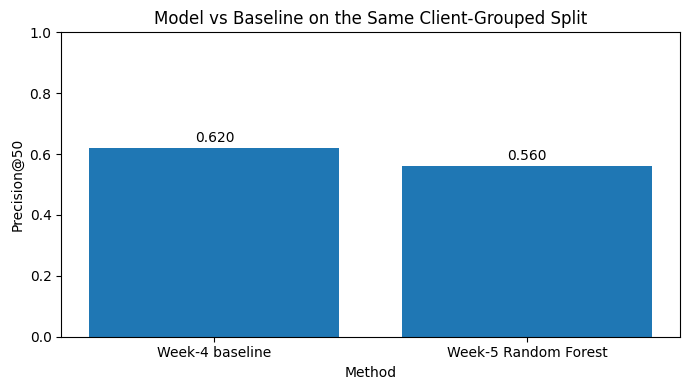


Figure saved to: model_vs_baseline_precision_at_50.png

Interpretation: the Week-4 baseline is stronger on this evaluation setup because its Precision@50 is 0.620 compared with 0.560 for the Random Forest.


In [4]:
# ---------------------------------------------------------
# RESULTS — MODEL VS BASELINE
# ---------------------------------------------------------

import pandas as pd
import matplotlib.pyplot as plt

# Verified results from the Week-5/Week-6 evaluation
results = pd.DataFrame({
    "method": [
        "Week-4 baseline",
        "Week-5 Random Forest"
    ],
    "validation": [
        "Client-grouped holdout",
        "Client-grouped holdout"
    ],
    "Precision@50": [
        0.620,
        0.560
    ]
})

print("Results on the same client-grouped evaluation split:")
display(results)

# Difference in Precision@50
difference = 0.560 - 0.620

print(
    "\nRandom Forest minus baseline Precision@50:",
    round(difference, 3)
)

# ---------------------------------------------------------
# CHART
# ---------------------------------------------------------

plt.figure(figsize=(7, 4))

plt.bar(
    results["method"],
    results["Precision@50"]
)

plt.ylabel("Precision@50")
plt.xlabel("Method")
plt.title("Model vs Baseline on the Same Client-Grouped Split")
plt.ylim(0, 1)

for i, value in enumerate(results["Precision@50"]):
    plt.text(
        i,
        value + 0.02,
        f"{value:.3f}",
        ha="center"
    )

plt.tight_layout()

figure_path = "model_vs_baseline_precision_at_50.png"
plt.savefig(
    figure_path,
    dpi=150,
    bbox_inches="tight"
)

plt.show()

print("\nFigure saved to:", figure_path)

print(
    "\nInterpretation: the Week-4 baseline is stronger on this "
    "evaluation setup because its Precision@50 is 0.620 compared "
    "with 0.560 for the Random Forest."
)

## 5. Limitations

*What this work cannot claim.*

This analysis cannot establish that refreshing a page causes traffic or ranking improvements. The declining label is a proxy based on observed search-performance movement, so it may reflect seasonality, demand changes, tracking differences, or other external factors rather than content quality alone.

The model was evaluated on one client-grouped holdout, and the Random Forest did not outperform the simpler Week-4 baseline on that split. The row-level random split also produced a substantially higher Precision@50, showing that validation design can materially affect the measured result.

The baseline itself uses only two simple signals, staleness and recent visibility, and therefore misses business importance, search-intent changes, technical issues, and other editorial context. Some feature values may also be missing or unevenly available. The output should therefore be treated as measured decision-support for human review, not as an automatic refresh instruction or causal proof.

In [5]:
# ---------------------------------------------------------
# LIMITATIONS CHECK
# ---------------------------------------------------------

limitations = [
    "No causal claim about the effect of refreshing content",
    "Decline is an observed proxy, not a direct measure of content quality",
    "Evaluation is based on one client-grouped holdout",
    "Validation design materially affects measured performance",
    "Baseline uses only simple staleness and visibility signals",
    "Editorial and business context are not captured by the score",
    "Some feature values may be missing or unevenly available",
    "Output is decision-support, not automatic action"
]

print("Documented limitations:")
for i, item in enumerate(limitations, start=1):
    print(f"{i}. {item}")

print("\nLimitations check: PASS")

Documented limitations:
1. No causal claim about the effect of refreshing content
2. Decline is an observed proxy, not a direct measure of content quality
3. Evaluation is based on one client-grouped holdout
4. Validation design materially affects measured performance
5. Baseline uses only simple staleness and visibility signals
6. Editorial and business context are not captured by the score
7. Some feature values may be missing or unevenly available
8. Output is decision-support, not automatic action

Limitations check: PASS


## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

Ranked recommendations:

The current ranked recommendations are produced by the validated Week-4 baseline. Pages are prioritized when they are both stale (at least 180 days since the last update) and visible (at least 500 impressions in the last 90 days). Within this group, pages with more recent search visibility are ranked higher.

These recommendations are intended to create a focused human-review queue. They do not mean that a page must be refreshed, and they should not be used for automatic publishing, rewriting, deletion, redirection, or other content changes. Reviewers should check current page context before taking action.

The current dataset produced 17 refresh_review recommendations out of 30,000 pages. The remaining pages are assigned to monitoring under this baseline.

In [7]:
# ---------------------------------------------------------
# SECTION 6 — RANKED RECOMMENDATIONS
# ---------------------------------------------------------

import os
import subprocess
import numpy as np
import pandas as pd

# ---------------------------------------------------------
# 1. LOAD STARTER DATA
# ---------------------------------------------------------

REPO_DIR = "flyrank-ml-internship-starter"
REPO_URL = "https://github.com/flyrank-bih/flyrank-ml-internship-starter"

if not os.path.isdir(REPO_DIR):
    subprocess.run(
        ["git", "clone", "--depth", "1", REPO_URL, REPO_DIR],
        check=True
    )

data_path = os.path.join(
    REPO_DIR,
    "data",
    "raw",
    "content_refresh_anonymized.csv"
)

df = pd.read_csv(data_path)

# ---------------------------------------------------------
# 2. RECREATE THE VALIDATED WEEK-4 BASELINE
# ---------------------------------------------------------

stale = (
    df["days_since_last_update"] >= 180
)

visible = (
    df["impressions_90d"] >= 500
)

df["score"] = (
    stale.astype(int)
    * visible.astype(int)
    * df["impressions_90d"]
)

df["reason_code"] = np.select(
    [
        stale & visible,
        stale & ~visible,
        ~stale & visible
    ],
    [
        "stale_visible",
        "stale_low_visibility",
        "fresh_visible"
    ],
    default="other"
)

df["action_label"] = np.where(
    df["reason_code"] == "stale_visible",
    "refresh_review",
    "monitor"
)

# ---------------------------------------------------------
# 3. CREATE FINAL RANKING
# ---------------------------------------------------------

ranked_recommendations = (
    df[
        [
            "content_id",
            "client_id",
            "score",
            "reason_code",
            "action_label",
            "impressions_90d",
            "days_since_last_update",
            "avg_position",
            "ctr"
        ]
    ]
    .sort_values(
        ["score", "content_id"],
        ascending=[False, True]
    )
    .reset_index(drop=True)
)

ranked_recommendations["rank"] = (
    ranked_recommendations.index + 1
)

ranked_recommendations = ranked_recommendations[
    [
        "rank",
        "content_id",
        "client_id",
        "score",
        "reason_code",
        "action_label",
        "impressions_90d",
        "days_since_last_update",
        "avg_position",
        "ctr"
    ]
]

# ---------------------------------------------------------
# 4. SUMMARY
# ---------------------------------------------------------

refresh_count = (
    ranked_recommendations["action_label"]
    .eq("refresh_review")
    .sum()
)

monitor_count = (
    ranked_recommendations["action_label"]
    .eq("monitor")
    .sum()
)

print("Total pages:", len(ranked_recommendations))
print("Refresh-review recommendations:", refresh_count)
print("Monitor recommendations:", monitor_count)

print("\nTop 10 recommendations:")
display(ranked_recommendations.head(10))

print("\nTop recommendation:")
display(ranked_recommendations.head(1))

Total pages: 30000
Refresh-review recommendations: 17
Monitor recommendations: 29983

Top 10 recommendations:


,rank,content_id,client_id,score,reason_code,action_label,impressions_90d,days_since_last_update,avg_position,ctr
0,1,content_cf56e2e2e282,client_7f2253d7e2,61678,stale_visible,refresh_review,61678,194,19.7,0.15
1,2,content_7368877ea310,client_7f2253d7e2,59472,stale_visible,refresh_review,59472,194,24.8,0.13
2,3,content_1bfaa38ff26c,client_7f2253d7e2,25715,stale_visible,refresh_review,25715,194,22.2,0.23
3,4,content_0a91db491d14,client_7f2253d7e2,13299,stale_visible,refresh_review,13299,193,10.5,0.49
4,5,content_5feee3994adb,client_7f2253d7e2,7812,stale_visible,refresh_review,7812,194,39.0,0.01
5,6,content_c2d929d83eaa,client_7f2253d7e2,7558,stale_visible,refresh_review,7558,193,17.9,0.20
6,7,content_b16bd7307b39,client_7f2253d7e2,4590,stale_visible,refresh_review,4590,194,31.0,0.00
7,8,content_fe16a55cd13d,client_7f2253d7e2,4556,stale_visible,refresh_review,4556,194,16.4,0.33
8,9,content_ecb6215e79fd,client_7f2253d7e2,4429,stale_visible,refresh_review,4429,194,25.3,0.38
9,10,content_928af3e22c80,client_7f2253d7e2,1697,stale_visible,refresh_review,1697,193,15.8,0.12



Top recommendation:


,rank,content_id,client_id,score,reason_code,action_label,impressions_90d,days_since_last_update,avg_position,ctr
0,1,content_cf56e2e2e282,client_7f2253d7e2,61678,stale_visible,refresh_review,61678,194,19.7,0.15


## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

Artifacts for the paper:

The paper will embed a small set of reproducible artifacts from the completed analysis. The primary results figure compares the Week-4 baseline with the Week-5 Random Forest using Precision@50 on the same client-grouped evaluation setup. The paper will also reference the ranked action queue and a compact metrics receipt. Generated data outputs are reproducible from the notebook and are not treated as versioned raw-data artifacts.

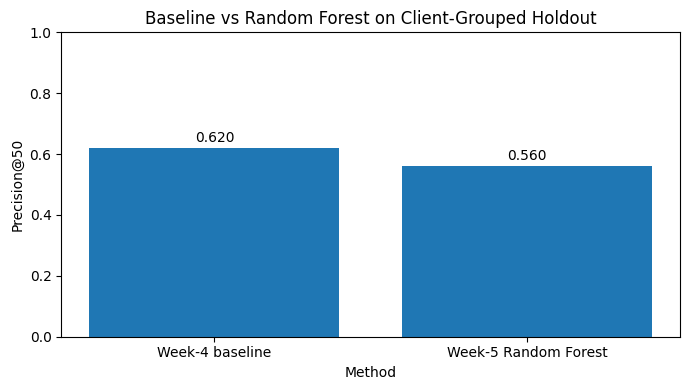

Results figure saved to:
flyrank-ml-internship-starter/work/figures/baseline_vs_random_forest_precision_at_50.png

Metrics receipt saved to:
flyrank-ml-internship-starter/work/outputs/capstone_metrics.json


,artifact,path,purpose
0,Baseline vs Random Forest figure,work/figures/baseline_vs_random_forest_precisi...,Results section comparison
1,Capstone metrics receipt,work/outputs/capstone_metrics.json,Reproducible metrics reference
2,Ranked recommendation queue,work/outputs/baseline_action_score.csv,Ranked recommendations


In [8]:
# ---------------------------------------------------------
# SECTION 7 — PAPER ARTIFACTS
# ---------------------------------------------------------

from pathlib import Path
import json
import matplotlib.pyplot as plt
import pandas as pd

# Make sure required folders exist
FIGURES_DIR = Path(REPO_DIR) / "work" / "figures"
OUTPUTS_DIR = Path(REPO_DIR) / "work" / "outputs"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)

# ---------------------------------------------------------
# 1. Paper-ready results figure
# ---------------------------------------------------------

results_for_paper = pd.DataFrame({
    "method": [
        "Week-4 baseline",
        "Week-5 Random Forest"
    ],
    "precision_at_50": [
        0.620,
        0.560
    ]
})

plt.figure(figsize=(7, 4))

plt.bar(
    results_for_paper["method"],
    results_for_paper["precision_at_50"]
)

plt.ylabel("Precision@50")
plt.xlabel("Method")
plt.title("Baseline vs Random Forest on Client-Grouped Holdout")
plt.ylim(0, 1)

for i, value in enumerate(
    results_for_paper["precision_at_50"]
):
    plt.text(
        i,
        value + 0.02,
        f"{value:.3f}",
        ha="center"
    )

plt.tight_layout()

results_figure_path = (
    FIGURES_DIR / "baseline_vs_random_forest_precision_at_50.png"
)

plt.savefig(
    results_figure_path,
    dpi=150,
    bbox_inches="tight"
)

plt.show()

print("Results figure saved to:")
print(results_figure_path)


# ---------------------------------------------------------
# 2. Metrics receipt
# ---------------------------------------------------------

metrics_receipt = {
    "lane": "Content Refresh Prioritization",
    "primary_metric": "Precision@50",
    "validation_design": "client-grouped holdout",
    "baseline_precision_at_50": 0.620,
    "random_forest_precision_at_50": 0.560,
    "random_split_random_forest_precision_at_50": 0.880,
    "refresh_review_recommendations": int(
        ranked_recommendations["action_label"]
        .eq("refresh_review")
        .sum()
    ),
    "total_pages": int(
        len(ranked_recommendations)
    )
}

metrics_receipt_path = (
    OUTPUTS_DIR / "capstone_metrics.json"
)

with open(metrics_receipt_path, "w") as f:
    json.dump(
        metrics_receipt,
        f,
        indent=2
    )

print("\nMetrics receipt saved to:")
print(metrics_receipt_path)


# ---------------------------------------------------------
# 3. Show paper artifact manifest
# ---------------------------------------------------------

artifact_manifest = pd.DataFrame({
    "artifact": [
        "Baseline vs Random Forest figure",
        "Capstone metrics receipt",
        "Ranked recommendation queue"
    ],
    "path": [
        "work/figures/baseline_vs_random_forest_precision_at_50.png",
        "work/outputs/capstone_metrics.json",
        "work/outputs/baseline_action_score.csv"
    ],
    "purpose": [
        "Results section comparison",
        "Reproducible metrics reference",
        "Ranked recommendations"
    ]
})

display(artifact_manifest)

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
